<div style="display: flex; align-items: center;">
    <h1 style="font-size: 3em; margin-right: 15px;">
        Physics Aware Recurrent Convolutional Neural Network (PARC): ShearFlow Equation Demo
    </h1>
    <div>
        <img src="../misc/VIL_logo.png" width="120" alt="Image 1" style="margin-right: 5px;" />
        <img src="../misc/uva.png" width="120" alt="Image 2" style="margin-right: 5px;" />
        <img src="../misc/iowa.png" width="120" alt="Image 3" />
    </div>
</div>

<p>
A customizable framework to embed physics in Deep Learning.
PARC's formulation is inspired by Advection-Diffusion-Reaction processes and uses an Inductive Bias approach to constrain the Neural Network.
</p>


# Modeling Shear Flow with PARC

This notebook aims to simulate the 2D periodic shear flow dynamics, a simplified version of the Navier-Stokes equation in a condition that it is incompressible (without consideration for pressure). A shear flow is a type of fluid that contains layers sliding past each other at varying velocities.

The notebook will guide you through from start to finish in preparing, training, and modeling the physics-based equation's prediction results. The notebook primarily covers three sections:
- loading and preparing the data for the Shear Flow's Equation
- Using the PARC Model to learn and predict the time evolution of velocity fields $u$ and tracer distributions $s$
- Evaluating the model's performance and compare predicted results to ground truth

# What exactly is a Shear Flow?

Shear Flows can be observed in many real life scenarios. For example, the air closest to an airplane's wings moves slower due to friction, while the air further way moves faster. This velocity difference in turn creates a shear flow and is critical for generating lift power for the plane. In a natural setting such as in rivers, water moves slower at the surface and faster at the river bed. The veloctiy gradient again creates 'stress' on the bed surface and thereby causes phenomenons like erotion or transportation of sediments.

Mathmatically, its primary equations governing the Shear Flow simulations are:

$$\frac{\partial u}{\partial t} + \nabla p - \nu \Delta u = -u\cdot \nabla u,$$

$$\frac{\partial s}{\partial t} - D\Delta s = -u \cdot \nabla s$$

In the first equation:
- $u$ is the velocity of the fluid 
- $\frac{\partial u}{\partial t}$ is the changes of velocity over time
- $\nabla p$ is the effect of pressure pushing the fluid around
- $\nu \Delta u$ describes the internal friction (viscosity) that resist fluid motion (**note:** $\nu$ stands for viscosity, $\Delta = \nabla \cdot \nabla$ it measures how 'curvy' something is, like a second-derivative that tells you whether you are at a global/local maximum, minimum, or a saddle point)
- $-u\cdot \nabla u$ describes the advection, meaning how a fluid that is already is motion is carrying itself along 

To sum up, this describes how changes in motion is equivalent to forces applied to the fluid due to **pressure** + **friction** - the fluid advection

In the second equation:
- $u$ again is the velocity vector of the fluid
- $s$ is the **flow tracer**, you can think of it as any substance/fluid property being carried by the fluid and is used to track flow velocity. (i.e. temperature, salinity, or dyes and small particles)
- $\frac{\partial s}{\partial t}$ describes how the tracer changes over time
- $-D\Delta s$ describes te natural diffusion/spreading of the tracer (I.e. how fast a substance spreads in water) (**note:** D stands for diffusivity, which measures how easily tracers spread)
- $-u\cdot \nabla s$ describes the rate of decrease of the tracer $s$ in the direction of the flow

This overall means that changes in tracer concentration equals how the tracer spreads out - how the tracer is moved around by the fluid

The two PDEs are **parameterized** by the Reynolds & Schmidt through $\nu$ and $D$ in the form of:

- **Viscosity**:
$$\nu = \frac{1}{Reynolds}$$
- **Diffusivity**:
$$D = \frac{\nu}{Schmidt}$$

# Goals of PARC for Shear Flow 

In this notebook we aim to use the PARC Neural Network to predict future **velocity fields $u$** and **tracer distributions $s$** based on current states. The neural network will be estimating the hidden physical parameters like $\nu$ and $D$ from the given observed Shear Flow data. This is essential as the neural network could learn not just the solutions to the predicted outcome of the shear flow at a future state, but also learning how the outcome changes/varies with different parameter values of **Viscosity** and **Diffusivity**




# Setting Up

This document serves as a guide to training a PARC model for the Shear Flow equation. Here are the initial steps to take before you begin training your PARC model!

Download & Prepare Data:
- Extract the downloaded data and ensure that it is placed in the following directory: `PARCtorch/PARCtorch/data`
- Make sure that the file paths at `train_dir` and `test_dir` point to the correct paths to your training and testing data, e.g. `../data/train` or `../data/test`

Install PARCtorch:
- Ensure PARCtorch is installed in your Python Environment, you could view the installation instructions [here](https://github.com/baeklab/PARCtorch/tree/main#installation)
- After the installation, install all the relevant dependencies with `!pip install -r requirements.txt` (The versions of your dependencies need to be <b>consistent</b> with our requirements, or else the script might not run!)
- Optional (only if the script doesn't run): add the root directory to the system's path so that it runs

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))


# Compute Data Normalization


In [2]:
import os, re, torch
from torch.utils.data import DataLoader
from PARCtorch.data.dataset import custom_collate_fn

# ensure GT shape is [B,T,C,H,W] 
def _to_BTCHW(gt, ic_BCHW):
    if gt.dim() != 5:
        raise ValueError(f"gt must be 5D, got {gt.shape}")
    B = ic_BCHW.shape[0]
    if gt.shape[0] == B:          # [B,T,C,H,W]
        return gt
    elif gt.shape[1] == B:        # [T,B,C,H,W] -> [B,T,C,H,W]
        return gt.permute(1,0,2,3,4).contiguous()
    else:
        raise ValueError(f"Can't infer B. ic B={B}, gt shape={gt.shape}")

def _sample_values(x, k):
    x = x.reshape(-1)
    n = x.numel()
    if n <= k:
        return x.detach().cpu()
    idx = torch.randint(0, n, (k,), device=x.device)
    return x[idx].detach().cpu()

# parse constants from filenames
_NUM = r"[0-9]*\.?[0-9]+(?:e[+-]?[0-9]+)?"
_re_re = re.compile(rf"Reynolds_({_NUM})")
_re_sc = re.compile(rf"Schmidt_({_NUM})")

def _to_float(s: str) -> float:
    return float(s)

def constants_from_filenames(folders, exts=(".hdf5", ".h5")):
    """Return sorted unique lists (Re_vals, Sc_vals) parsed from filenames in given folder(s)."""
    if isinstance(folders, (str, os.PathLike)):
        folders = [folders]
    re_vals, sc_vals = set(), set()
    for folder in folders:
        if not os.path.isdir(folder):
            continue
        for name in os.listdir(folder):
            if not name.endswith(exts):
                continue
            m_re = _re_re.search(name)
            m_sc = _re_sc.search(name)
            if m_re: re_vals.add(_to_float(m_re.group(1)))
            if m_sc: sc_vals.add(_to_float(m_sc.group(1)))
    return sorted(re_vals), sorted(sc_vals)

@torch.no_grad()
def scan_minmax(
    dataset,
    *,
    batches=20,
    bs=70,
    center_pressure=True,
    pct=99.5,
    const_start=4,
    sample_per_map=2048,
    max_total_samples=1_000_000,
    parse_constants_from_folders=None,   # <— pass your train/val folder(s) here
):
    """
    Returns:
      min_val_tensor, max_val_tensor (per-channel):
      [tracer_min, pressure_min, -1, -1, const1_min, const2_min, ...]
    """
    dl = DataLoader(
        dataset, batch_size=bs, shuffle=True,
        num_workers=0, pin_memory=False, collate_fn=custom_collate_fn
    )

    tr_samples, pr_samples = [], []
    const_vals = None 

    seen = 0
    for ic, t0, t1, gt in dl:
        gt = _to_BTCHW(gt, ic)  # [B,T,C,H,W]
        B, T, C, H, W = gt.shape
        ic2, gt2 = ic.clone(), gt.clone()

        if center_pressure and C >= 2:
            ic2[:, 1]    -= ic2[:, 1].mean(dim=(-2,-1), keepdim=True)
            gt2[:, :, 1] -= gt2[:, :, 1].mean(dim=(-2,-1), keepdim=True)

        # sample tracer & pressure (IC + GT)
        tr_samples.append(_sample_values(ic2[:, 0], sample_per_map))
        pr_samples.append(_sample_values(ic2[:, 1], sample_per_map))
        tr_samples.append(_sample_values(gt2[:, :, 0].reshape(B*T, H, W), sample_per_map))
        pr_samples.append(_sample_values(gt2[:, :, 1].reshape(B*T, H, W), sample_per_map))

        # fallback constants from tensors if no parsing specified
        if parse_constants_from_folders is None and C > const_start:
            n_const = C - const_start
            if const_vals is None:
                const_vals = [[] for _ in range(n_const)]
            for j in range(n_const):
                const_vals[j].append(ic2[:, const_start + j, 0, 0].detach().cpu())

        seen += 1
        if batches is not None and seen >= batches:
            break

        # cap lists
        def _cap_list(L):
            total = sum(t.numel() for t in L)
            if total > max_total_samples:
                cat = torch.cat(L)
                new_n = max_total_samples // 2
                idx = torch.randint(0, cat.numel(), (new_n,))
                L.clear(); L.append(cat[idx])
        _cap_list(tr_samples); _cap_list(pr_samples)

    # percentiles
    def _percentile(sample_list, q):
        if not sample_list: return 0.0
        x = torch.cat(sample_list).float()
        return float(torch.quantile(x, torch.tensor(q, dtype=torch.float32)))

    low_q = (100.0 - pct) / 100.0
    hi_q  = pct / 100.0
    tr_min = _percentile(tr_samples, low_q)
    tr_max = _percentile(tr_samples, hi_q)
    pr_min = _percentile(pr_samples, low_q)
    pr_max = _percentile(pr_samples, hi_q)

    # velocities are unit-normalized in your dataset
    vx_min, vx_max = -1.0, 1.0
    vy_min, vy_max = -1.0, 1.0

    # search min max of reynolds and constants via file names
    const_mins, const_maxs = [], []
    if parse_constants_from_folders is not None:
        re_list, sc_list = constants_from_filenames(parse_constants_from_folders)
        if re_list:
            eps = 1e-8
            const_mins.append(min(re_list) - eps)
            const_maxs.append(max(re_list) + eps)
        if sc_list:
            eps = 1e-8
            const_mins.append(min(sc_list) - eps)
            const_maxs.append(max(sc_list) + eps)
        print(f"[files] Reynolds from names: {re_list or '—'}")
        print(f"[files] Schmidt  from names: {sc_list or '—'}")

    min_list = [tr_min, pr_min, vx_min, vy_min] + const_mins
    max_list = [tr_max, pr_max, vx_max, vy_max] + const_maxs
    min_val_tensor = torch.tensor(min_list, dtype=torch.float32)
    max_val_tensor = torch.tensor(max_list, dtype=torch.float32)

    print(f"[stream] tracer   pct[{100-pct:.1f}%,{pct:.1f}%]: {tr_min:.4f}, {tr_max:.4f}")
    print(f"[stream] pressure pct[{100-pct:.1f}%,{pct:.1f}%]: {pr_min:.4f}, {pr_max:.4f}" +
          (" (centered)" if center_pressure else ""))
    print(f"[stream] velocity: UNIT NORMALIZED → [-1.0, 1.0]")
    if const_mins:
        print(f"[const] mins: {const_mins}")
        print(f"[const] maxs: {const_maxs}")

    return min_val_tensor, max_val_tensor


In [3]:
from torch.utils.data import DataLoader
import torch
import os
import h5py
from PARCtorch.data.welldataset_single_trajectory import WellDatasetInterface
from the_well.data.datasets import WellDataset
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, Resize
import PARCtorch.data.dataset as ds_mod
import torch
import torch.nn as nn
train_dir = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/train"
# Now import the utilities
from PARCtorch.data.dataset import (
    custom_collate_fn,
    InitialConditionDataset,
    initial_condition_collate_fn,
)
from PARCtorch.utilities.viz import (
    visualize_channels,
    save_gifs_with_ground_truth,
)

ds_mod.WellDatasetInterface.__del__ = lambda self: None

# spatial transforms
orig_h, orig_w = 256, 512
spatial_percent = 1/3
new_h = int(orig_h * spatial_percent)  # 85
new_w = int(orig_w * spatial_percent)  # 170

def divisible_by_8(x):
    return (x//8)*8
new_h = divisible_by_8(new_h)
new_w = divisible_by_8(new_w)


patch_size = (new_h, new_w)

# spatial transformation
train_spatial_transform = Compose([
    Resize((new_h, new_w)),
])
gt_spatial_transform = Compose([
    Resize((new_h, new_w)),
])

# temporal skipping
temporal_skip = 50
desired_frames = 3
future_steps = 1

batch_size = 60
loader = WellDatasetInterface(
    well_dataset_args={"path": train_dir, "exclude_filters": ["shear_flow_Reynolds_5e5_Schmidt_1e0.hdf5"]},
    future_steps=future_steps,
    add_constant_scalars=True,
    delta_t=2,
    temporal_skip=temporal_skip,
    spatial_transform=train_spatial_transform,
    min_val=None, max_val=None,
    single_trajectory=False,
)

# calculate min max tensors
min_val_tensor, max_val_tensor = scan_minmax(
    loader,
    batches=60,          
    bs=64,
    center_pressure=True,  
    pct=99.5,
    const_start=4,
    sample_per_map=4096,
    max_total_samples=2_000_000,
    parse_constants_from_folders=[train_dir],
)


print("min_val_tensor:", min_val_tensor.tolist())
print("max_val_tensor:", max_val_tensor.tolist())



In [5]:
import torch
from pathlib import Path

def load_minmax(cache_path, expected_len=None, dtype=torch.float32):
    """
    Load min/max for use INSIDE a Dataset/DataLoader worker.
    Always returns CPU tensors to avoid CUDA init in workers.
    """
    ckpt = torch.load(Path(cache_path), map_location="cpu")

    # Extract
    if isinstance(ckpt, dict):
        min_t = ckpt.get("min", ckpt.get("min_val_tensor"))
        max_t = ckpt.get("max", ckpt.get("max_val_tensor"))
    elif isinstance(ckpt, (list, tuple)) and len(ckpt) >= 2:
        min_t, max_t = ckpt[0], ckpt[1]
    else:
        raise ValueError(f"Unsupported cache format in {cache_path}")

    if min_t is None or max_t is None:
        keys = list(ckpt.keys()) if isinstance(ckpt, dict) else []
        raise ValueError(f"Could not find min/max in {cache_path}. Keys: {keys}")

    # Ensure CPU tensors
    min_t = torch.as_tensor(min_t, dtype=dtype).contiguous().cpu()
    max_t = torch.as_tensor(max_t, dtype=dtype).contiguous().cpu()

    if expected_len is not None and (min_t.numel() != expected_len or max_t.numel() != expected_len):
        print(f"Warning: expected {expected_len} channels, got {min_t.numel()}/{max_t.numel()}")

    return min_t, max_t


# Usage
cache_file = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/minmax_cache.pt"
min_val_tensor, max_val_tensor = load_minmax(cache_file, expected_len=6)
print("min:", min_val_tensor.tolist())
print("max:", max_val_tensor.tolist())


min: [-0.5, -0.4064001441001892, -1.0, -1.0, 10000.0, 0.19999998807907104]
max: [0.5, 0.14997883141040802, 1.0, 1.0, 500000.0, 5.0]


# Load Training Data

In [6]:
import os
import h5py
from PARCtorch.data.welldataset_single_trajectory import WellDatasetInterface
from the_well.data.datasets import WellDataset
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, Resize
import PARCtorch.data.dataset as ds_mod
import torch
import torch.nn as nn
train_dir = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/train"
# Now import the utilities
from PARCtorch.data.dataset import (
    custom_collate_fn,
    InitialConditionDataset,
    initial_condition_collate_fn,
)
from PARCtorch.utilities.viz import (
    visualize_channels,
    save_gifs_with_ground_truth,
)

ds_mod.WellDatasetInterface.__del__ = lambda self: None

# spatial transforms
orig_h, orig_w = 256, 512
spatial_percent = 1/3
new_h = int(orig_h * spatial_percent)  # 85
new_w = int(orig_w * spatial_percent)  # 170

def divisible_by_8(x):
    return (x//8)*8
new_h = divisible_by_8(new_h)
new_w = divisible_by_8(new_w)


patch_size = (new_h, new_w)

# spatial transformation
train_spatial_transform = Compose([
    Resize((new_h, new_w)),
])
gt_spatial_transform = Compose([
    Resize((new_h, new_w)),
])

# temporal skipping
temporal_skip = 50
desired_frames = 3
future_steps = 1

batch_size = 10 # increase it to see at which point it will reduce the training time 


# Remove corrupted files
corrupted = []
if os.path.isdir(train_dir):
    for fname in os.listdir(train_dir):
        if not fname.endswith(".hdf5"):
            continue
        fpath = os.path.join(train_dir, fname)
        try:
            with h5py.File(fpath, "r"):
                pass
        except OSError:
            corrupted.append(fname)
            os.remove(fpath)


# Initialize dataset
ds = WellDatasetInterface(
    well_dataset_args={
        "path": train_dir,
        "exclude_filters": ["shear_flow_Reynolds_5e5_Schmidt_1e0.hdf5"]
    },
    future_steps=future_steps,
    add_constant_scalars = True,
    delta_t = 2,
    temporal_skip = temporal_skip,
    spatial_transform = train_spatial_transform,
    min_val= min_val_tensor,
    max_val= max_val_tensor,
    single_trajectory=True,
    traj_idx=0,
)

ic, t0, t1, gt = ds[0]


# Create DataLoader for training dataset
train_loader = DataLoader(
    ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=1,
    collate_fn=custom_collate_fn,
    pin_memory=False,
)

val_dir = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/experimental_validation"
val_dataset = WellDatasetInterface(
    well_dataset_args={"path": val_dir},
    future_steps=future_steps,
    delta_t=2.0,
    add_constant_scalars=True,
    temporal_skip=temporal_skip,
    spatial_transform=gt_spatial_transform,
    min_val=min_val_tensor,
    max_val=max_val_tensor,
    single_trajectory=True,
    traj_idx=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    collate_fn=custom_collate_fn,
)



# Sanity check on normalization

In [7]:
# Grab one batch from your DataLoader
xb, t0, t1, yb = next(iter(train_loader))   # xb: [B, C, H, W], yb: [T, B, C, H, W]

B, C, H, W = xb.shape
print("xb shape:", xb.shape, "yb shape:", yb.shape)

if C < 4:
    raise RuntimeError(f"Expected at least 4 field channels (tracer, pressure, vx, vy); got C={C}")

# In your pipeline, the last 4 channels are the field group: [tracer, pressure, vx, vy]
tr_pr_slice = slice(C - 4, C - 2)  # tracer, pressure
vx_idx = C - 2
vy_idx = C - 1

def minmax(t):
    t = t.detach()
    return float(t.min().cpu()), float(t.max().cpu())

# --- Inputs (ic) ---
tr_pr_min, tr_pr_max = minmax(xb[:, tr_pr_slice])
vx_min, vx_max = minmax(xb[:, vx_idx])
vy_min, vy_max = minmax(xb[:, vy_idx])
print(f"IC tracer/pressure ~[0,1]: [{tr_pr_min:.4f}, {tr_pr_max:.4f}]")
print(f"IC vx ~[-1,1]: [{vx_min:.4f}, {vx_max:.4f}]")
print(f"IC vy ~[-1,1]: [{vy_min:.4f}, {vy_max:.4f}]")

# --- Targets (gt) ---
T = yb.shape[0]
tr_pr_min_t, tr_pr_max_t = minmax(yb[:, :, tr_pr_slice])
vx_min_t, vx_max_t = minmax(yb[:, :, vx_idx])
vy_min_t, vy_max_t = minmax(yb[:, :, vy_idx])
print(f"GT tracer/pressure ~[0,1] over T={T}: [{tr_pr_min_t:.4f}, {tr_pr_max_t:.4f}]")
print(f"GT vx ~[-1,1]: [{vx_min_t:.4f}, {vx_max_t:.4f}]")
print(f"GT vy ~[-1,1]: [{vy_min_t:.4f}, {vy_max_t:.4f}]")

# --- Optional: constants (everything before last 4 channels) ---
if C > 4:
    const_min, const_max = minmax(xb[:, :C-4])
    print(f"IC constants (e.g., Re/Sc/constant_fields) ~[0,1]: [{const_min:.4f}, {const_max:.4f}]")


xb shape: torch.Size([10, 6, 80, 168]) yb shape: torch.Size([1, 10, 6, 80, 168])
IC tracer/pressure ~[0,1]: [-1.0000, 1.0000]
IC vx ~[-1,1]: [0.0000, 0.1837]
IC vy ~[-1,1]: [0.0000, 1.0000]
GT tracer/pressure ~[0,1] over T=1: [-1.0000, 1.0000]
GT vx ~[-1,1]: [0.0000, 0.1837]
GT vy ~[-1,1]: [0.0000, 1.0000]
IC constants (e.g., Re/Sc/constant_fields) ~[0,1]: [-0.3994, 1.0000]


# Visualizing the Data - Sanity Check

This step is a sanity-check on one of the batches to ensure that our previous two steps - **normalization** and **data loading** were carried out correctly. 

To do so, we will be plotting out the:
- **Initial Condition** `ic`: The initial physical state of the system at time $t_0$ - the input to the model
- **Time Stamp** `t0`: The time stamp corresponding to the initial condition
- **Target Timestamp** `t1`: The target time stamp that we are trying to predict with PARC
- **Ground Truth** `target`: The ground truth data at time $t_1$, representing what the model is suppoesd to output at the predicted outcome at the future time stamp
- `channel_names`: labels for each channel, i.e. `Reynolds,Schmidt, tracer, pressure, velocity_U, velocity_V `
- `channel_cmaps`: list of colormaps for each channel

Channel Data Statistics:
Channel 0: IC min=0.15200187265872955, IC max=0.9207032918930054
  Step 1: min=0.1520480513572693, max=0.9204034209251404
Channel 1: IC min=0.6897211670875549, IC max=0.7649035453796387
  Step 1: min=0.691247284412384, max=0.7637747526168823
Channel 2: IC min=-1.0, IC max=1.0
  Step 1: min=-1.0, max=1.0
Channel 3: IC min=-0.9999988675117493, IC max=0.9999984502792358
  Step 1: min=-0.9999969005584717, max=0.9999999403953552
Channel 4: IC min=0.0, IC max=0.0
  Step 1: min=0.0, max=0.0
Channel 5: IC min=0.062499985098838806, IC max=0.0625000149011612
  Step 1: min=0.062499985098838806, max=0.0625000149011612


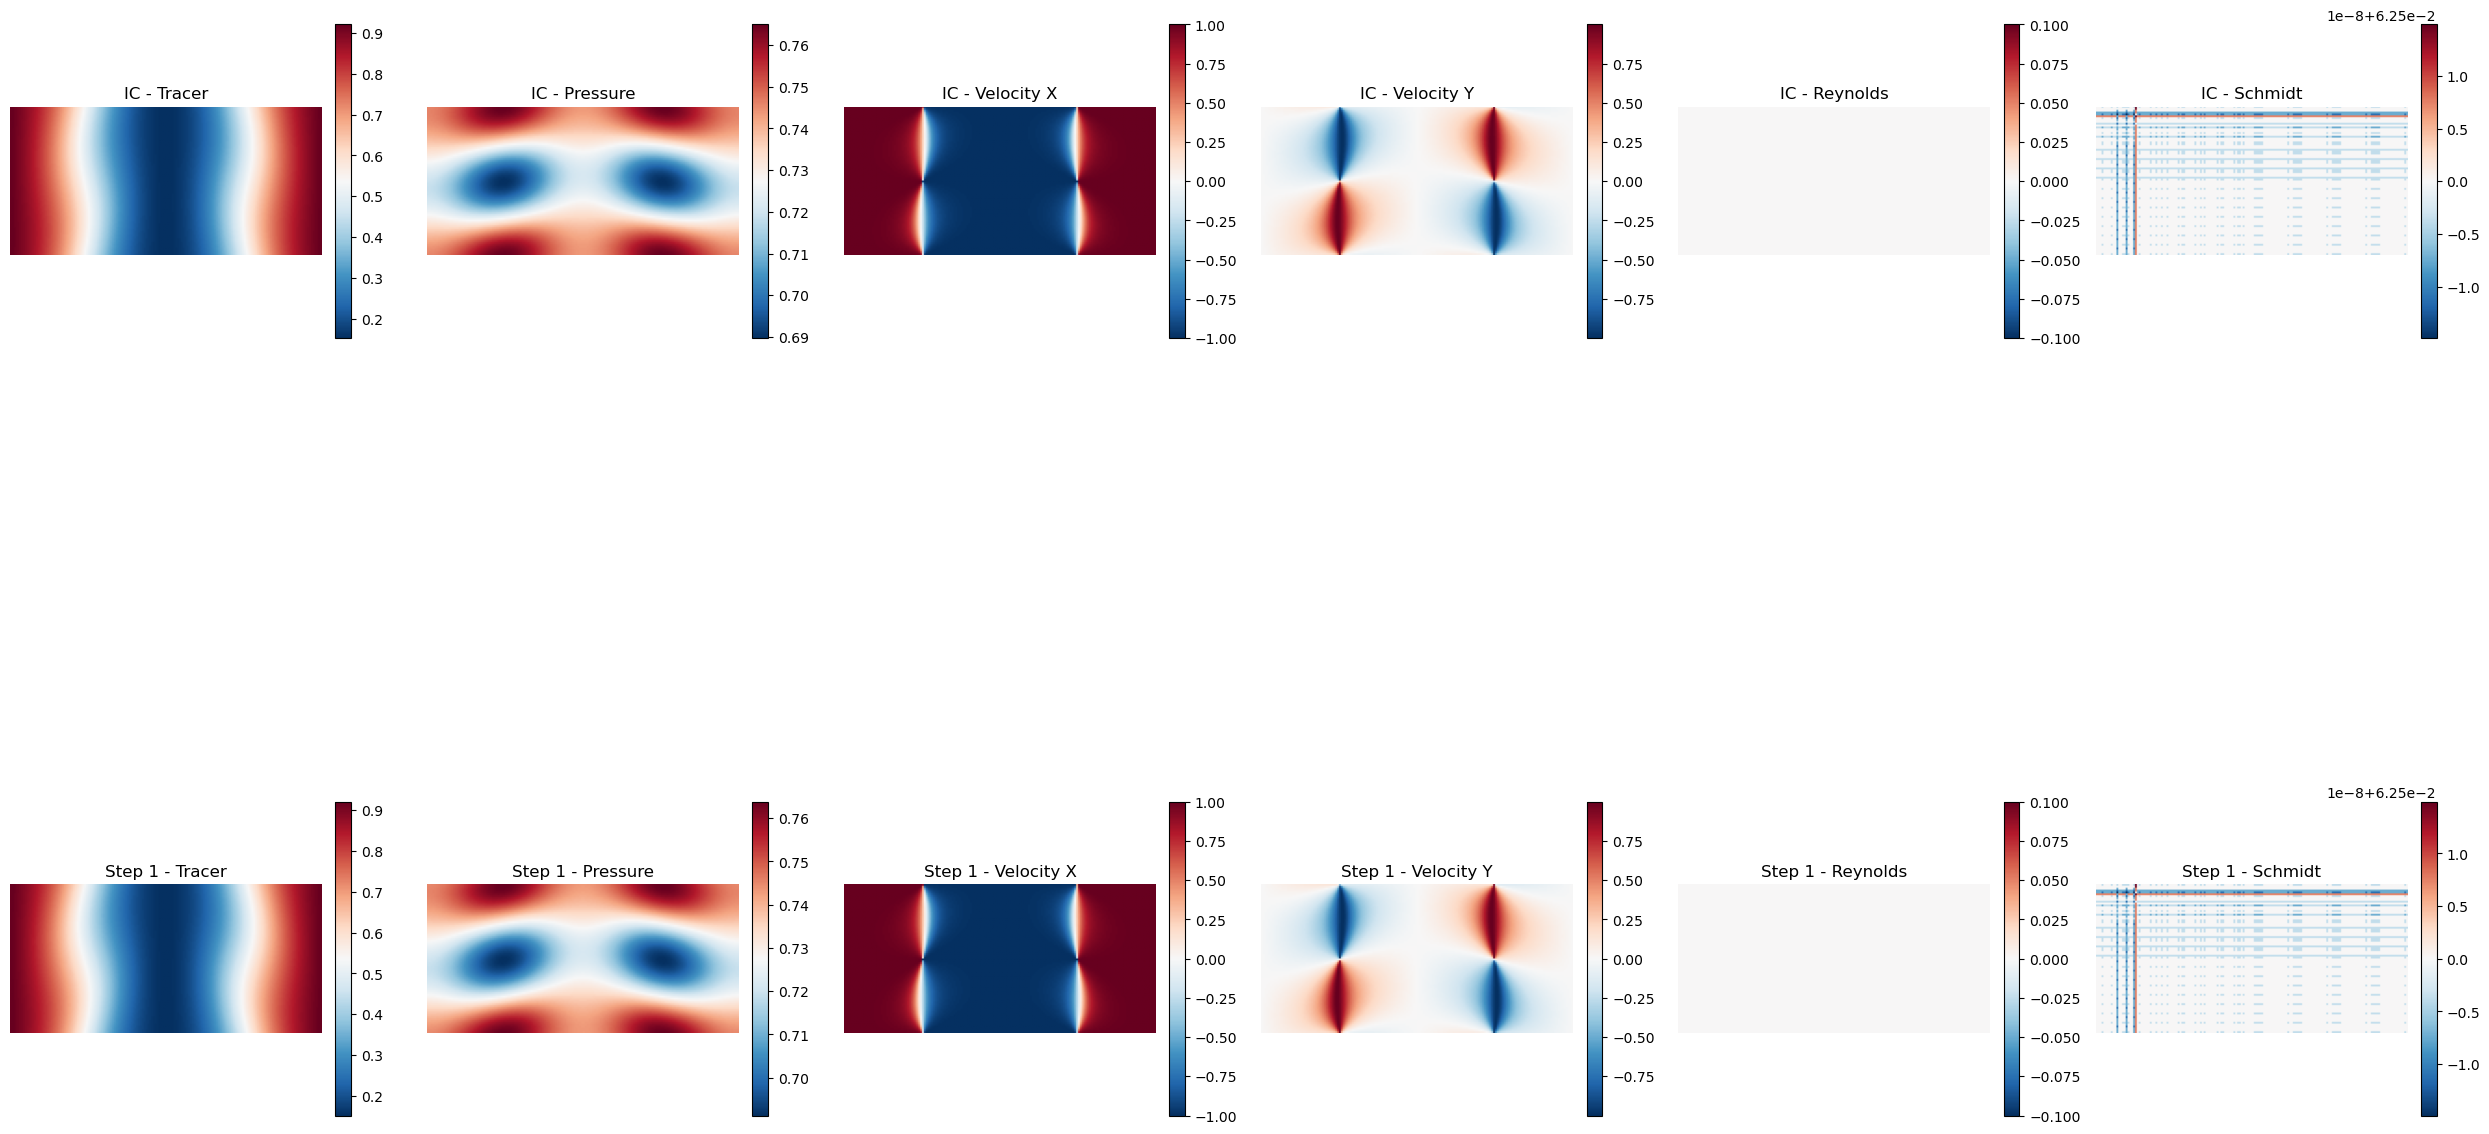

In [8]:
# Fetch a batch and visualize
for batch in train_loader:
    ic, t0, t1, target = batch
    
    num_channels = ic.shape[1]
    
    channel_names = [ 
        "Tracer",
        "Pressure",
        "Velocity X",
        "Velocity Y",
        "Reynolds",
        "Schmidt",
    ]
    assert len(channel_names) == num_channels, \
        f"Expected {num_channels} channel names, got {len(channel_names)}"
    
    custom_cmaps = ["RdBu_r"] * num_channels

    visualize_channels(
        ic,
        t0,
        t1,
        target,
        channel_names=channel_names,
        channel_cmaps=custom_cmaps,
    )
    break  # Visualize one batch for now

# Building the PARC Model

In [9]:
from PARCtorch.PARCv2 import PARCv2
from PARCtorch.differentiator.differentiator import ADRDifferentiator
from PARCtorch.differentiator.finitedifference import FiniteDifference
from PARCtorch.integrator.integrator import Integrator
#from PARCtorch.integrator.heun import Heun
from PARCtorch.integrator.rk4 import RK4  
from PARCtorch.integrator.euler import Euler
from PARCtorch.utilities.unet import UNet

from torch.optim import Adam

# Defining 2D Imcompressible Shear Flow
PARCv2.check = lambda self: True 
PARCv2.check_msg = lambda self, chk: None 

n_fe_features = 64

unet_sf = UNet(
    block_dimensions = [64, 64* 2, 64 * 4],  
    input_channels = 6, 
    output_channels = n_fe_features,
    kernel_size = 3,
    padding_mode = "circular",
    up_block_use_concat=[False, True],  
    skip_connection_indices=[0],  
)

right_diff = FiniteDifference(padding_mode="circular").cuda()  # Use replication padding to handle boundary conditions

base_diff = ADRDifferentiator(
    n_state_var = 2,  
    n_const_var = 2,
    n_fe_features = n_fe_features,  
    list_adv_idx=[0, 1, 2, 3],                    
    list_dif_idx=[0, 1, 2, 3],  
    feature_extraction = unet_sf,  
    padding_mode = "circular",  
    finite_difference_method = right_diff,  
    spade_random_noise = False 
).cuda()

sf_diff = base_diff

rk4 = RK4().cuda() # RK4
euler = Euler().cuda() # euler

# sf_int = Integrator(
#     clip = False,  
#     list_poi_idx=[],  
#     num_int = euler,  
#     list_dd_int = [None, None, None, None, None, None],  
#     padding_mode = "circular",  
#     finite_difference_method = right_diff,  
#     poi_kernel_size = 3, 
#     n_poi_features = 64
# ).cuda()

sf_int = Integrator(
    clip=False,
    list_poi_idx=[],                 
    num_int=rk4,
    list_dd_int=[None, None, None],  
    padding_mode="circular",
    finite_difference_method=right_diff,
    poi_kernel_size=3,
    n_poi_features=64,
    velocity_idx=(2, 3),
    const_start=4
).cuda()

# Define the loss function (L1 Loss is typically used for regression tasks)
criterion = torch.nn.L1Loss().cuda()

# Initialize the PARCv2 model with the differentiator, integrator, and loss function
model = PARCv2(
    sf_diff, 
    sf_int, 
    criterion
).cuda()

# Set up the optimizer (Adam is a popular choice for adaptive learning rate optimization)
optimizer = Adam(
    model.parameters(), 
    lr=1e-4
)  

# Training the Model

## First round of training

In [10]:
from train import train_model
from pathlib import Path
import pickle
import gc, torch, time

gc.collect()
torch.cuda.empty_cache()

save_dirs = Path("/home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights")
save_dirs.mkdir(exist_ok=True, parents=True)

cumulative_path = save_dirs / "training_losses_cumulative.pkl"
cumulative_losses = []

num_epochs = 1000
global_start = time.time()

best_val_loss = float("inf")
best_epoch = None
best_checkpoint_path = save_dirs / "best_validation.pt"
raw_best_path = save_dirs / "model.pth"

for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()

    # training one epoch
    train_start = time.time()
    train_model(
        model,
        train_loader,
        criterion,
        optimizer,
        num_epochs=1,
        save_dir=save_dirs,
        app='ns',
    )
    train_time = time.time() - train_start

    # Load the epochs' training losses
    loss_path = save_dirs / "training_losses.pkl"
    with open(loss_path, 'rb') as f:
        epoch_losses = pickle.load(f)

    cumulative_losses.extend(epoch_losses)
    with open(cumulative_path, 'wb') as f:
        pickle.dump(cumulative_losses, f)

    latest_loss = epoch_losses[-1] if epoch_losses else float("nan")  # training loss

    # validate the losses via the validation loader
    val_start = time.time()
    model.eval()
    val_losses = []
    val_batch_times = []
    with torch.no_grad():
        for ic, t0, t1, gt in val_loader:
            batch_start = time.time()
            ic, t0, t1, gt = ic.cuda(), t0.cuda(), t1.cuda(), gt.cuda()
            pred = model(ic, t0.squeeze(), t1)
            val_losses.append(criterion(pred, gt).item())
            val_batch_times.append(time.time() - batch_start)
    val_time = time.time() - val_start
    if val_losses:
        val_loss = float(sum(val_losses) / len(val_losses))
    else:
        val_loss = float("nan")
    avg_val_batch_time = val_time / len(val_batch_times) if val_batch_times else 0.0

    # Timing and ETA
    epoch_time = time.time() - epoch_start
    elapsed = time.time() - global_start
    eta_secs = (elapsed / epoch) * (num_epochs - epoch)


    print(
        f"Epoch {epoch:4d}/{num_epochs}  "
        f"TrainLoss {latest_loss:.6f}  ValLoss {val_loss:.6f}  "
        f"TrainTime {train_time:.2f}s  ValTime {val_time:.2f}s  "
        f"(avg val batch {avg_val_batch_time:.3f}s)  "
        f"⏱ Epoch {epoch_time:.2f}s  ETA {eta_secs:.2f}s",
        flush=True
    )

    # saving regular checkpoints
    ckpt_dict = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': latest_loss,
        'val_loss': val_loss,
    }
        
    latest_checkpoint_path = save_dirs / "latest.pt"
    torch.save(ckpt_dict, latest_checkpoint_path)
    
    if epoch % 2 == 0:
        checkpoint_path = save_dirs / f"checkpoint_epoch_{epoch:04d}.pt"
        torch.save(ckpt_dict, checkpoint_path)
        print(f"saved checkpoint: {checkpoint_path} (train_loss={latest_loss:.6f}, val_loss={val_loss:.6f})", flush=True)
    else:
        print(f"updated latest checkpoint (epoch {epoch})", flush=True)
    
    # save best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': latest_loss,
            'val_loss': val_loss,
        }, best_checkpoint_path)
        print(f"saved new best model (val_loss={val_loss:.6f}) to {best_checkpoint_path}", flush=True)
    
        torch.save(model.state_dict(), raw_best_path)
    
    gc.collect()
    torch.cuda.empty_cache()

print(f"\n saved cumulative losses to: {cumulative_path}")
print(f"Best validation epoch: {best_epoch} with val_loss={best_val_loss:.6f}")


## Second Round of training (resuming off the last one)

Assumes `model`, `train_loader`, `val_loader`, `criterion`, and `optimizer` are already instantiated.

In [ ]:
from train import train_model
from pathlib import Path
import pickle
import gc, torch, time, signal, os, tempfile  

save_dirs = Path("/home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights")
save_dirs.mkdir(exist_ok=True, parents=True)

cumulative_path = save_dirs / "training_losses_cumulative.pkl"
raw_best_path = save_dirs / "model.pth"  # synced raw best weights
best_checkpoint_path = save_dirs / "best_validation.pt"

num_epochs = 1000  # total target epochs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def atomic_torch_save(obj, path: Path):
    """Write checkpoint atomically to avoid partial files."""
    path = Path(path)
    with tempfile.NamedTemporaryFile(dir=path.parent, delete=False) as tmp:
        tmp_path = Path(tmp.name)
    torch.save(obj, tmp_path)
    os.replace(tmp_path, path)  # atomic on POSIX

def try_load_ckpt(path: Path, map_location):
    """Reject obviously partial files; try torch.load with a clear error."""
    if not path.is_file():
        raise FileNotFoundError(path)
    if path.stat().st_size < (1 << 20):  # if file is < 1MB, it is very likely partial/corrupt
        raise RuntimeError(f"too small ({path.stat().st_size} bytes)")
    return torch.load(path, map_location=map_location)

# resume state holders
best_val_loss = float("inf")
best_epoch = None
total_elapsed = 0.0  # accumulated over all previous epochs (if resumed)
start_epoch = 1
cumulative_losses = []

# load existing cumulative losses if any 
if cumulative_path.exists():
    try:
        with open(cumulative_path, "rb") as f:
            cumulative_losses = pickle.load(f)
    except Exception:
        cumulative_losses = []

# load best validation loss
if best_checkpoint_path.exists():
    try:
        ckpt = torch.load(best_checkpoint_path, map_location=device)
        if isinstance(ckpt, dict):
            best_val_loss = ckpt.get("val_loss", best_val_loss)
            best_epoch = ckpt.get("epoch", best_epoch)
    except Exception as e:
        print(f"[resume] warning: cannot read best_validation.pt: {e}")

# find latest checkpoint in storage to resume
ckpt_files = sorted(
    [p for p in save_dirs.glob("checkpoint_epoch_*.pt") if p.is_file()],
    key=lambda p: p.stat().st_mtime, reverse=True
)
for p in ckpt_files:
    try:
        ckpt = try_load_ckpt(p, map_location=device)
        if "model_state_dict" in ckpt:
            model.load_state_dict(ckpt["model_state_dict"])
        else:
            model.load_state_dict(ckpt)  # fallback raw state_dict
        if "optimizer_state_dict" in ckpt:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        # restore best validation if present
        best_val_loss = ckpt.get("val_loss", best_val_loss)
        best_epoch = ckpt.get("epoch", best_epoch)
        total_elapsed = ckpt.get("total_elapsed", 0.0)
        start_epoch = ckpt.get("epoch", 0) + 1
        print(f"[resume] loaded checkpoint {p.name} ({p.stat().st_size} bytes): "
              f"resuming from epoch {start_epoch}, best_val_loss={best_val_loss:.6f}, "
              f"best_epoch={best_epoch}, total_elapsed={total_elapsed:.1f}s")
        break
    except Exception as e:
        print(f"[resume] skipping {p.name}: {e}")
else:
    ckpt = None  

# shut down 
state = {"terminate": False}
def handle_sigterm(signum, frame):
    print("Received SIGTERM; will finish current epoch and exit cleanly.", flush=True)
    state["terminate"] = True
signal.signal(signal.SIGTERM, handle_sigterm)

# training loop 
for epoch in range(start_epoch, num_epochs + 1):
    epoch_start = time.time()

    model.train()
    train_start = time.time()
    train_model(
        model,
        train_loader,
        criterion,
        optimizer,
        num_epochs=1,
        save_dir=save_dirs,
        app='ns',
    )
    train_time = time.time() - train_start

    # load the epoch's training loss
    try:
        loss_path = save_dirs / "training_losses.pkl"
        with open(loss_path, "rb") as f:
            epoch_losses = pickle.load(f)
    except Exception:
        epoch_losses = []

    cumulative_losses.extend(epoch_losses)
    with open(cumulative_path, "wb") as f:
        pickle.dump(cumulative_losses, f)

    latest_loss = epoch_losses[-1] if epoch_losses else float("nan")

    # compute validation loss
    val_start = time.time()
    model.eval()
    val_losses = []
    val_batch_times = []
    with torch.no_grad():
        for ic, t0, t1, gt in val_loader:
            batch_start = time.time()
            ic, t0, t1, gt = ic.to(device), t0.to(device), t1.to(device), gt.to(device)  # MOD: .to(device)
            pred = model(ic, t0.squeeze(), t1)   # assumes PARC expects t0 scalar, t1 vector
            val_losses.append(criterion(pred, gt).item())
            val_batch_times.append(time.time() - batch_start)
    val_time = time.time() - val_start
    val_loss = float(sum(val_losses) / len(val_losses)) if val_losses else float("nan")
    avg_val_batch_time = val_time / len(val_batch_times) if val_batch_times else 0.0

    # update ETA of model finishing training
    epoch_time = time.time() - epoch_start
    total_elapsed += epoch_time
    epochs_done = epoch
    eta_secs = (total_elapsed / epochs_done) * (num_epochs - epochs_done)

    print(
        f"Epoch {epoch:4d}/{num_epochs}  "
        f"TrainLoss {latest_loss:.6f}  ValLoss {val_loss:.6f}  "
        f"TrainTime {train_time:.2f}s  ValTime {val_time:.2f}s  "
        f"(avg val batch {avg_val_batch_time:.3f}s)  "
        f"⏱ Epoch {epoch_time:.2f}s  ETA {eta_secs:.2f}s  TotalElapsed {total_elapsed:.1f}s",
        flush=True
    )

    # Save regular checkpoints
    checkpoint_path = save_dirs / f"checkpoint_epoch_{epoch:04d}.pt"
    atomic_torch_save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': latest_loss,
        'val_loss': val_loss,
        'total_elapsed': total_elapsed,
    }, checkpoint_path)
    print(f"saved checkpoint: {checkpoint_path} (train_loss={latest_loss:.6f}, val_loss={val_loss:.6f})", flush=True)

    # loading model with best validation
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        atomic_torch_save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': latest_loss,
            'val_loss': val_loss,
            'total_elapsed': total_elapsed,
        }, best_checkpoint_path)
        atomic_torch_save(model.state_dict(), raw_best_path)
        print(f"saved new best model (val_loss={val_loss:.6f}) to {best_checkpoint_path}", flush=True)
        print(f"also updated raw best weights to {raw_best_path}", flush=True)

    gc.collect()
    if torch.cuda.is_available():  # MOD: guard
        torch.cuda.empty_cache()

    if state["terminate"]:
        print(f"Terminating early after epoch {epoch} due to signal. Progress saved.", flush=True)
        break

# summary statistics printing
print(f"\nSaved cumulative losses to: {cumulative_path}")
print(f"Best validation epoch: {best_epoch} with val_loss={best_val_loss:.6f}")
done_flag = save_dirs / "done.flag"
done_flag.write_text("training complete" if epochs_done >= num_epochs else "interrupted")


[resume] loaded checkpoint checkpoint_epoch_0340.pt (20415435 bytes): resuming from epoch 341, best_val_loss=0.057239, best_epoch=340, total_elapsed=0.0s


Epoch 1/1: 100%|██████████| 239/239 [02:34<00:00,  1.55it/s, Batch Loss=0.000517]

Epoch [1/1], Average Loss: 0.0010
Model weights saved at /home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights/model.pth
Training losses saved at /home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights/training_losses.pkl


Epoch  341/1000  TrainLoss 0.000964  ValLoss 0.061729  TrainTime 154.71s  ValTime 16.29s  (avg val batch 0.407s)  ⏱ Epoch 171.01s  ETA 330.49s  TotalElapsed 171.0s
saved checkpoint: /home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights/checkpoint_epoch_0341.pt (train_loss=0.000964, val_loss=0.061729)


Epoch 1/1: 100%|██████████| 239/239 [02:34<00:00,  1.55it/s, Batch Loss=0.000606]

...

Epoch  370/1000  TrainLoss 0.000920  ValLoss 0.062260  TrainTime 149.42s  ValTime 15.82s  (avg val batch 0.396s)  ⏱ Epoch 165.27s  ETA 8325.71s  TotalElapsed 4889.7s
saved checkpoint: /home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights/checkpoint_epoch_0370.pt (train_loss=0.000920, val_loss=0.062260)


Epoch 1/1: 100%|██████████| 239/239 [02:32<00:00,  1.57it/s, Batch Loss=0.00112] 

Epoch [1/1], Average Loss: 0.0009
Model weights saved at /home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights/model.pth
Training losses saved at /home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights/training_losses.pkl


Epoch  371/1000  TrainLoss 0.000910  ValLoss 0.059690  TrainTime 152.24s  ValTime 10.07s  (avg val batch 0.252s)  ⏱ Epoch 162.32s  ETA 8565.28s  TotalElapsed 5052.0s
saved checkpoint: /home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_RK4_debug_model_weights/checkpoint_epoch_0371.pt (train_loss=0.000910, val_loss=0.059690)


Epoch 1/1:  81%|████████  | 193/239 [01:58<00:27,  1.66it/s, Batch Loss=0.00127] 

# Loading the Model

In [ ]:
from PARCtorch.utilities.load import load_model_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_weights_path = "/home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_Euler_model_weights/model.pth"  # Replace with your path
model = load_model_weights(model, model_weights_path, device)

# Creating the Sequence DataLoader

Now its time to test out our model on the testing dataset!

To do so, we must first redo everything we did during the training stage - but for the new testing data. We first load the test samples using the same `WellDatasetInterface`, except that we'll be pointing towards the validation test dataset of the directory.

After that we again wrap them in a `DataLoader` for sample batching (same as what we did in the training stage). 

In [ ]:
from torch.utils.data import DataLoader, SequentialSampler
from PARCtorch.data.welldataset_single_trajectory import WellDatasetInterface
from PARCtorch.data.dataset import initial_condition_collate_fn, custom_collate_fn

test_dir = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/test"
single_train_dir = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/single_file"
experimental_train_dir = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/experimental_train"
train_dir = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/train"
val_dir = "/home/wkt7ne/PARCtorch/PARCtorch/shear_flow/data/validation"

path = test_dir

future_steps = 199
batch_size   = 20
temporal_skips = 10

gt_spatial_transform = Compose([
    Resize((new_h, new_w)),
])

# seq_dataset = WellDatasetInterface(
#     well_dataset_args = {
#         "path": path,
#         #"exclude_filters": ["shear_flow_Reynolds_5e5_Schmidt_1e0.hdf5"],
#         "max_rollout_steps": future_steps
#     },
#     future_steps = future_steps,
#     delta_t = 2.0,
#     min_val = min_val_tensor,
#     max_val = max_val_tensor,
#     temporal_skip = temporal_skips,
#     spatial_transform = gt_spatial_transform,
#     add_constant_scalars= True, 
#     single_trajectory=False,
#     #traj_idx=0
# )

# ic, t0, t1, gt = seq_dataset[0]
# seq_dataset.transform = gt_spatial_transform

# seq_loader = DataLoader(
#     seq_dataset,
#     batch_size = batch_size,
#     shuffle = False,
#     num_workers = 1,
#     pin_memory = True,
#     collate_fn = initial_condition_collate_fn,
# )

# ic, t0, t1, gt = seq_dataset[0]
# print("IC shape:", ic.shape)        # expect [C, 80, 168]
# print("GT shape:", gt.shape)        # expect [T_out, C, 80, 168]
# print("len(t1):", len(t1)) 

# Loading Ground Truths

In [ ]:
# Initialize the dataset

# "exclude_filters": ["shear_flow_Reynolds_5e5_Schmidt_1e0.hdf5"]
gt_dataset = WellDatasetInterface(
    well_dataset_args = {
        "path": path,
        "exclude_filters": ["shear_flow_Reynolds_5e5_Schmidt_1e0.hdf5"],
        "max_rollout_steps": future_steps
    },
   future_steps = future_steps,
   delta_t = 2.0,
   add_constant_scalars= True,
   temporal_skip = temporal_skips,         
   spatial_transform = gt_spatial_transform,  
   min_val = min_val_tensor,
   max_val = max_val_tensor,
   single_trajectory = True,
   traj_idx = 0,
)

gt_loader = DataLoader(
    gt_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    collate_fn=custom_collate_fn,
)

# Rollout and Snapshot Prediction

In [ ]:
import os, numpy as np, torch, matplotlib.pyplot as plt, imageio

mode = "rollout"                                  # snapshot or rollout
out_dir = "/home/wkt7ne/PARCtorch/PARCtorch/demos/gifs"
figsize, dpi, fps = (6, 3), 120, 6
const_start = 4                                    # first index of constant channels
keep_constants = True
center_p_for_viz = True
pressure_pct = (1, 95)                            # reserved for future pressure scaling (unused)

# rollout visualization stabilizers
safe_dt = 1                                      # if dataset delta_t > safe_dt, use substeps
nan_guard = True                                   # replace NaN/Inf with 0
unit_velocity = True                              # normalize (vx, vy) to unit length

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
os.makedirs(out_dir, exist_ok=True)

# Batch
gt_ic, gt_t0, gt_t1, gt = next(iter(gt_loader))    # ic:[B,C,H,W], t0:[], t1:[T], gt:[T,B,C,H,W]
gt_ic, gt_t0, gt_t1, gt = gt_ic.to(device), gt_t0.to(device), gt_t1.to(device), gt.to(device)
t0_abs = gt_t0.squeeze()                           # scalar absolute start time
t1_vec = gt_t1.flatten()                           # [T] absolute target times
base_dt = float(t1_vec[0] - t0_abs)                # assumed uniform dataset step

@torch.no_grad()
def predict_next_state(x, t_prev_abs, t_next_abs):
    """Advance state from t_prev_abs to t_next_abs in one model call. Return shape [B,C,H,W]."""
    y = model(x, t_prev_abs, t_next_abs.view(1))
    if y.ndim == 5: y = y[-1]
    if y.ndim == 3: y = y.unsqueeze(0)
    return y

@torch.no_grad()
def constrain_state(x, ic, const_start=4, unit_velocity=True, nan_guard=True, keep_constants=True):
    """Ensure valid shape; optional NaN removal; pin constants; center pressure; normalize velocity."""
    if x.ndim == 5: x = x[-1]
    if x.ndim == 3: x = x.unsqueeze(0)
    if ic.ndim == 3: ic = ic.unsqueeze(0)
    if nan_guard:
        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    if keep_constants and x.shape[1] > const_start and ic.shape[1] >= x.shape[1]:
        x[:, const_start:] = ic[:, const_start:]
    if x.shape[1] >= 2:
        p = x[:, 1:2]
        x[:, 1:2] = p - p.mean(dim=(-2, -1), keepdim=True)
    if unit_velocity and x.shape[1] >= 4:
        eps = 1e-12
        vx, vy = x[:, 2:3], x[:, 3:4]
        speed = torch.sqrt(vx*vx + vy*vy + eps)
        x[:, 2:3], x[:, 3:4] = vx / speed, vy / speed
    if nan_guard:
        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return x

def pick_color_limits_from_ground_truth(ch, a_gt, pressure_pct=(1, 99)):
    """Channel-wise color limits:
       tracer: fixed [0,1]; pressure: ±percentile of |GT fluctuations|;
       velocity: [-1,1]; other: GT 1–99th percentile."""
    if ch == 0:  # tracer
        return 0.0, 1.0
    if ch == 1:  # pressure (symmetric about 0)
        a = a_gt - a_gt.mean(axis=(1, 2), keepdims=True)
        hi = float(pressure_pct[1])               # <- actually use your setting
        v  = float(max(np.percentile(np.abs(a), hi), 1e-6))
        return -v, v
    if ch in (2, 3):  # velocities
        return -1.0, 1.0
    lo, hi = np.percentile(a_gt, [1, 99])
    return float(lo), float(hi)


# model inference logic
T = gt.shape[0]
if mode == "snapshot":
    pred_steps = []
    for k in range(T):
        prev_state = gt_ic if k == 0 else gt[k-1]
        t_prev, t_next = (t0_abs if k == 0 else t1_vec[k-1]), t1_vec[k]
        y = predict_next_state(prev_state, t_prev, t_next)
        y = constrain_state(y, gt_ic, const_start, unit_velocity, nan_guard, keep_constants)
        pred_steps.append(y)
    pred = torch.stack(pred_steps, dim=0)
elif mode == "rollout":
    """rollout with optional substeps to improve stability and accuracy."""
    pred_steps, x = [], gt_ic.clone()
    t_prev_abs = t0_abs
    for i in range(T):
        t_next_abs = t_prev_abs + base_dt
        n_sub = max(1, int(np.ceil(abs(base_dt) / safe_dt)))
        if n_sub > 1:
            sub_times = torch.linspace(float(t_prev_abs), float(t_next_abs), n_sub+1, device=device)[1:]
            y, tp = x, t_prev_abs
            for tn in sub_times:
                y = predict_next_state(y, tp, tn)
                y = constrain_state(y, gt_ic, const_start, unit_velocity, nan_guard, keep_constants)
                tp = tn
            x = y
        else:
            y = predict_next_state(x, t_prev_abs, t_next_abs)
            x = constrain_state(y, gt_ic, const_start, unit_velocity, nan_guard, keep_constants)
        pred_steps.append(x)
        t_prev_abs = t_next_abs
    pred = torch.stack(pred_steps, dim=0)
else:
    raise ValueError("mode must be 'snapshot' or 'rollout'")

# Plotting preparation
T = min(pred.shape[0], gt.shape[0])
C = min(pred.shape[2], gt.shape[2])
pred, gt = pred[:T, :, :C], gt[:T, :, :C]
preds_np = pred.detach().cpu().numpy()
gts_np = gt.detach().cpu().numpy()
batch0 = 0
c_fields = min(4, C)
c_const = max(0, C - c_fields)
field_names = ["tracer", "pressure", "velocity_x", "velocity_y"][:c_fields]
const_names = ["reynolds", "schmidt"][:c_const] + [f"const{j}" for j in range(max(0, c_const-2))]
names = field_names + const_names
cmaps = ["RdBu_r", "RdBu_r", "seismic", "seismic"][:c_fields] + (["seismic"] * c_const)

def center_frames_for_display(arr):
    """Center array by subtracting spatial mean per frame (display only)."""
    return arr - arr.mean(axis=(1, 2), keepdims=True)

# Plotting
for ch in range(C):
    a_pred = preds_np[:, batch0, ch].copy()
    a_gt = gts_np[:, batch0, ch].copy()
    vmin, vmax = pick_color_limits_from_ground_truth(ch, a_gt, pressure_pct)
    if center_p_for_viz and ch == 1:
        a_pred = center_frames_for_display(a_pred)
        a_gt = center_frames_for_display(a_gt)
    a_pred_vis = np.clip(a_pred, vmin, vmax)
    frames = []
    for ti in range(T):
        fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi, constrained_layout=True)
        im0 = axes[0].imshow(a_pred_vis[ti], cmap=cmaps[ch], vmin=vmin, vmax=vmax, interpolation="nearest")
        im1 = axes[1].imshow(a_gt[ti], cmap=cmaps[ch], vmin=vmin, vmax=vmax, interpolation="nearest")
        
        cbar = fig.colorbar(im1, ax=axes, fraction=0.05, pad=0.02)

        if ch == 0:  # tracer color bar fix
            cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
        
        axes[0].set_title(f"{names[ch]} (pred) | frame {ti+1}/{T}", fontsize=9)
        axes[1].set_title(f"{names[ch]} (gt)   | frame {ti+1}/{T}", fontsize=9)
        for ax in axes: ax.axis("off")
        fig.canvas.draw()
        buf, (wbuf, hbuf) = fig.canvas.print_to_buffer()
        frames.append(np.frombuffer(buf, dtype=np.uint8).reshape(hbuf, wbuf, 4)[..., :3])
        plt.close(fig)
    gif_path = os.path.join(out_dir, f"{mode}_ch{ch:02d}_{names[ch]}.gif")
    imageio.mimsave(gif_path, frames, fps=fps)
    print("wrote", gif_path)


# Visualizing the Loss Curve 



Finally, to monitor the model's learning progress and ensure that the optimization is happening correctly, it's important to plot the loss curve over each training epoch. Overall, a decreasing loss trend will indicate that the model is minimizing the loss function as intended. 

**To do so, we:**

1. Load the saved training loss history from the pickle file, which was recorded durin the training to a designated directory.

2. Plot the loss against epochs to visualize how the model's performance changes over time

3. Save the loss curve image for future references

**How to diagnose your model performances:**

- **Steadily decreasing loss (Ideal)**: suggests that the model is learning effectively, and that its predictions are getting closer to the ground truth as training progresses.

    - Consider stopping early (reducing `num_epochs`) if the validation stabilizes at an earlier point of the training iterations.
    
- **Loss increases or becomes erratic**: numerical instability due to large spatial inputs, or suggests that perhaps the batch size is too large for GPU memory, causing gradient accumulation fragmentation. 

    - Consider reducing `batch_size` to free up more memory for GPU.


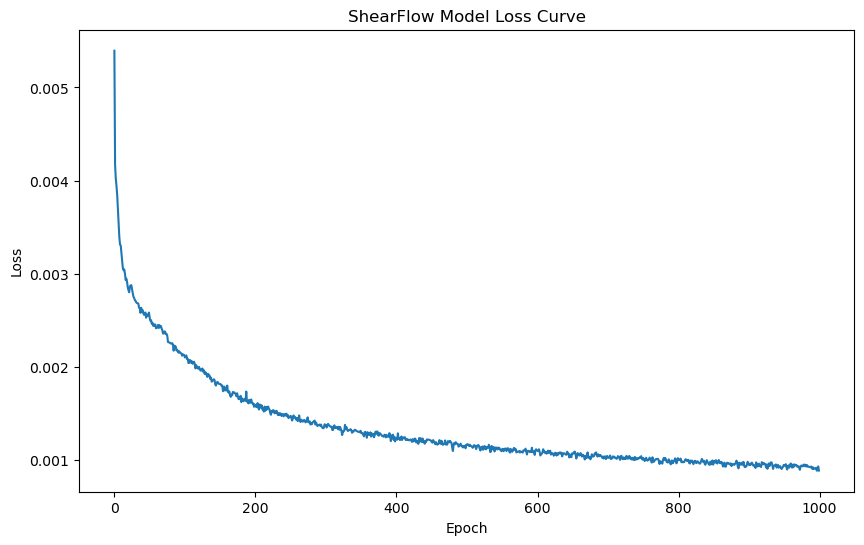

In [1]:
import pickle
import matplotlib.pyplot as plt

# Find your training_'losses.pkl' file in the directory that you stored your trained model weights in
with open( "/home/wkt7ne/PARCtorch/PARCtorch/demos/results/SF_Euler_debug_model_weights/training_losses_cumulative.pkl", 'rb' ) as f:  # replace with your path
    history = pickle.load(f)
plt.figure(figsize=(10,6))
plt.title('ShearFlow Model Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(history)
#plt.xlim(99, 500)
plt.savefig('normalization_loss_curve.png')
 

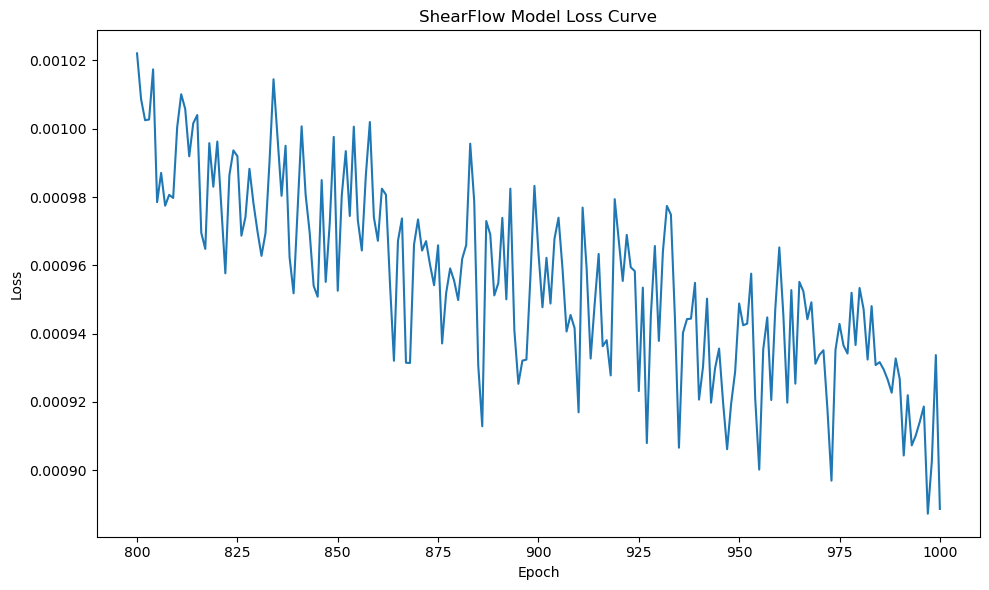

In [3]:
start, end = 800, 1000                   # epoch numbers (1-based)
start_idx = max(0, start - 1)              # convert to 0-based index
end_idx   = min(len(history), end)         # slice end is exclusive


epochs = range(start, end_idx + 1)         # x-axis as epoch numbers
losses = history[start_idx:end_idx]

plt.figure(figsize=(10,6))
plt.title('ShearFlow Model Loss Curve')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.plot(epochs, losses)
plt.tight_layout()
plt.savefig('normalization_loss_curve_100_500.png')
